In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **Task 1 — Data Import & Setup**

In [ ]:
# ○ Import CSV using Pandas

df= pd.read_csv("https://raw.githubusercontent.com/maha0210ms-hue/Datasets/refs/heads/main/social_media_engagement_5000.csv")

df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,12-02-2023,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,23-05-2023,383936,False,mobile,negative,#travel,2.777372


In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           5000 non-null   int64  
 1   age               4850 non-null   float64
 2   gender            4850 non-null   object 
 3   country           5000 non-null   object 
 4   post_id           5000 non-null   int64  
 5   post_type         5000 non-null   object 
 6   post_category     5000 non-null   object 
 7   likes             4850 non-null   float64
 8   comments          4850 non-null   float64
 9   shares            4850 non-null   float64
 10  watch_time_sec    5000 non-null   int64  
 11  impression_count  5000 non-null   int64  
 12  posted_at         5000 non-null   object 
 13  follower_count    5000 non-null   int64  
 14  is_verified       5000 non-null   bool   
 15  device_type       5000 non-null   object 
 16  sentiment         4850 non-null   object 


In [ ]:
# ○ Check/convert data types
df[["age", "likes", "comments", "shares"]] = (df[["age", "likes", "comments", "shares"]].astype("Int64"))


In [ ]:
# ○ Convert date columns to datetime
df["posted_at"] = pd.to_datetime(df['posted_at'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           5000 non-null   int64         
 1   age               4850 non-null   Int64         
 2   gender            4850 non-null   object        
 3   country           5000 non-null   object        
 4   post_id           5000 non-null   int64         
 5   post_type         5000 non-null   object        
 6   post_category     5000 non-null   object        
 7   likes             4850 non-null   Int64         
 8   comments          4850 non-null   Int64         
 9   shares            4850 non-null   Int64         
 10  watch_time_sec    5000 non-null   int64         
 11  impression_count  5000 non-null   int64         
 12  posted_at         5000 non-null   datetime64[ns]
 13  follower_count    5000 non-null   int64         
 14  is_verified       5000 n

# **Task 2 — Data Cleaning**

In [ ]:
# ●  Cleaning Missing Data
# ■ Detect missing values (isnull(), isna())

In [ ]:
df.isna().sum()

,0
user_id,0
age,150
gender,150
country,0
post_id,0
post_type,0
post_category,0
likes,150
comments,150
shares,150


In [ ]:
df.isnull().mean()*100

,0
user_id,0.0
age,3.0
gender,3.0
country,0.0
post_id,0.0
post_type,0.0
post_category,0.0
likes,3.0
comments,3.0
shares,3.0


In [ ]:
# ■ Handle using: dropna(), fillna(), median/mode, forward/backward-fill

numerical_cols= ['age','likes','comments','shares']
df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].median().round())

In [ ]:
df.isna().sum()

,0
user_id,0
age,0
gender,150
country,0
post_id,0
post_type,0
post_category,0
likes,0
comments,0
shares,0


In [ ]:
cat_col = ['gender','sentiment']

for col in cat_col:
  df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
df.isna().sum()

,0
user_id,0
age,0
gender,0
country,0
post_id,0
post_type,0
post_category,0
likes,0
comments,0
shares,0


In [ ]:
# ● Duplicate Handling- Identify & remove duplicates
df.duplicated(subset=['post_id']).sum()

np.int64(9)

In [ ]:
df=df.drop_duplicates(subset='post_id')

In [ ]:
#  Data Formatting
# ■ Fix incorrect data types

df[['age','likes','shares','comments']] = df[['age','likes','shares','comments']].astype("int")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4991 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           4991 non-null   int64         
 1   age               4991 non-null   int64         
 2   gender            4991 non-null   object        
 3   country           4991 non-null   object        
 4   post_id           4991 non-null   int64         
 5   post_type         4991 non-null   object        
 6   post_category     4991 non-null   object        
 7   likes             4991 non-null   int64         
 8   comments          4991 non-null   int64         
 9   shares            4991 non-null   int64         
 10  watch_time_sec    4991 non-null   int64         
 11  impression_count  4991 non-null   int64         
 12  posted_at         4991 non-null   datetime64[ns]
 13  follower_count    4991 non-null   int64         
 14  is_verified       4991 non-nu

In [ ]:
# ■ Standardize categories (e.g., gender labels)
df['gender'].unique()

array(['Female', 'Male', 'Other'], dtype=object)

In [ ]:
print(df['country'].unique())
print(df['post_type'].unique())
print(df['post_category'].unique())
print(df['device_type'].unique())

['Brazil' 'UK' 'France' 'Canada' 'Japan' 'Australia' 'India' 'UAE'
 'Germany' 'USA']
['image' 'reel' 'text' 'video']
['fitness' 'food' 'tech' 'travel' 'fashion' 'lifestyle' 'education'
 'music']
['mobile' 'tablet' 'desktop']


In [ ]:
df['country'] = df['country'].str.strip()
df['post_type'] = df['post_type'].str.strip().str.capitalize()
df['post_category'] = df['post_category'].str.strip().str.capitalize()
df['device_type'] = df['device_type'].str.strip().str.capitalize()
df['hashtags'] = df['hashtags'].str.strip()

In [ ]:
# ■ Correct unrealistic values in likes, comments, shares

df[['likes','shares','comments']].describe()

,likes,shares,comments
count,4991.000000,4991.000000,4991.000000
mean,10105.861751,1002.897015,1501.511921
std,5703.628073,570.842898,856.683226
min,10.000000,0.000000,0.000000
25%,5224.500000,511.000000,791.000000
50%,10106.000000,1012.000000,1497.000000
75%,14965.000000,1482.500000,2234.500000
max,19998.000000,1999.000000,2999.000000


In [ ]:
# ●  Feature Cleaning
# ■ Extract hashtag count

df[['hashtags']].assign(hashtag_count=df['hashtags'].str.count('#'))

,hashtags,hashtag_count
0,#foodie #travel #love,3
1,#fitness,1
2,#foodie,1
3,#music #foodie #fun,3
4,#travel,1
...,...,...
4995,#travel #fun,2
4996,#foodie #reels,2
4997,#lifestyle #tech,2
4998,#reels #love #fitness,3


In [ ]:
# ■ Clean sentiment labels
df['sentiment'] = df['sentiment'].str.strip().str.title()

# **Task 3 — Data Exploration using Pandas**

In [ ]:
# ● View dataset structure using head(), tail(), shape, and columns.
df.head(10)

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43,Female,Brazil,496713,Image,Fitness,7011,354,1157,5726,44650,2022-12-17,81734,False,Mobile,Negative,#foodie #travel #love,0.190862
1,10860,33,Male,Brazil,157326,Reel,Food,11750,2606,1807,5947,80216,2023-06-02,5963,False,Mobile,Negative,#fitness,0.201493
2,86820,32,Female,UK,109864,Text,Food,4862,344,955,6946,44858,2023-05-07,501783,False,Tablet,Positive,#foodie,0.137345
3,64886,51,Other,France,848877,Text,Fitness,5350,1083,1049,229,70455,2023-02-12,480212,False,Mobile,Negative,#music #foodie #fun,0.106195
4,16265,34,Other,UK,449706,Image,Fitness,12682,2735,1300,4798,6019,2023-05-23,383936,False,Mobile,Negative,#travel,2.777372
5,92386,16,Other,Canada,174310,Video,Tech,12535,1790,99,1427,24893,2023-09-16,684761,False,Desktop,Positive,#fitness,0.579440
6,47194,25,Male,Japan,481598,Video,Travel,11703,2276,1465,6287,96327,2022-04-15,519759,True,Tablet,Negative,#music,0.160329
7,97498,57,Female,Canada,343415,Image,Travel,9611,146,424,1699,68446,2023-12-20,698739,False,Desktop,Neutral,#travel #music #fitness,0.148745
8,54131,54,Female,UK,907449,Image,Fashion,10106,2379,1897,5650,36283,2023-07-06,615809,True,Desktop,Negative,#music #fun #fitness,0.533914
9,70263,62,Female,Australia,495037,Video,Lifestyle,14106,2480,1053,3969,87972,2022-11-16,452146,False,Tablet,Neutral,#lifestyle #love,0.200507


In [ ]:
df.tail(10)

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
4989,21874,59,Male,USA,189299,Reel,Fitness,5019,2588,414,6937,91810,2023-06-01,634508,False,Tablet,Positive,#travel #foodie,0.087365
4990,96402,54,Female,Germany,924979,Video,Fitness,3574,175,1155,2029,89706,2022-02-28,457481,False,Tablet,Neutral,#love #music #foodie,0.054667
4991,24079,42,Male,France,994186,Text,Food,6546,1443,1839,1143,84178,2023-08-11,620133,False,Tablet,Negative,#lifestyle #reels #fitness,0.116753
4992,59850,44,Female,Japan,860814,Reel,Tech,19407,1755,397,4346,51236,2022-01-16,49851,False,Tablet,Neutral,#reels #love #foodie,0.420778
4994,19018,54,Male,India,613622,Image,Tech,14677,2948,1176,5418,17003,2023-05-01,85261,False,Desktop,Neutral,#fashion,1.105746
4995,59500,44,Male,Australia,441541,Video,Education,16210,2013,1837,6190,42977,2022-06-25,646147,False,Mobile,Positive,#travel #fun,0.466761
4996,22100,38,Other,UAE,677076,Reel,Education,16924,2734,1583,7764,34196,2022-11-18,584603,False,Desktop,Negative,#foodie #reels,0.621155
4997,67021,63,Female,USA,273595,Text,Travel,13487,1497,167,7466,23680,2023-04-06,483550,False,Desktop,Positive,#lifestyle #tech,0.679688
4998,29800,13,Female,Germany,785644,Video,Fitness,16894,1289,1713,4991,89013,2022-05-16,183295,False,Tablet,Positive,#reels #love #fitness,0.223518
4999,73400,54,Other,Japan,712252,Text,Travel,14830,503,1798,3743,14234,2023-03-04,585760,False,Desktop,Neutral,#foodie #lifestyle #fashion,1.203527


In [ ]:
df.shape

(4991, 19)

In [ ]:
df.columns

Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'posted_at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate'],
      dtype='object')

In [ ]:
# ● Check data types and info with info() and dtypes.
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4991 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           4991 non-null   int64         
 1   age               4991 non-null   int64         
 2   gender            4991 non-null   object        
 3   country           4991 non-null   object        
 4   post_id           4991 non-null   int64         
 5   post_type         4991 non-null   object        
 6   post_category     4991 non-null   object        
 7   likes             4991 non-null   int64         
 8   comments          4991 non-null   int64         
 9   shares            4991 non-null   int64         
 10  watch_time_sec    4991 non-null   int64         
 11  impression_count  4991 non-null   int64         
 12  posted_at         4991 non-null   datetime64[ns]
 13  follower_count    4991 non-null   int64         
 14  is_verified       4991 non-nu

In [ ]:
df.dtypes

,0
user_id,int64
age,int64
gender,object
country,object
post_id,int64
post_type,object
post_category,object
likes,int64
comments,int64
shares,int64


In [ ]:
# ● Generate summary statistics using describe().

df.describe()

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,engagement_rate
count,4991.000000,4991.000000,4991.000000,4991.000000,4991.000000,4991.000000,4991.000000,4991.000000,4991,4991.000000,4991.000000
mean,54547.943699,38.439591,547854.825486,10105.861751,1501.511921,1002.897015,4015.120617,50029.706872,2022-12-28 10:38:12.286115072,393904.683631,0.964971
min,10055.000000,13.000000,100068.000000,10.000000,0.000000,0.000000,0.000000,105.000000,2022-01-01 00:00:00,87.000000,0.006363
25%,32281.000000,26.000000,322410.000000,5224.500000,791.000000,511.000000,2023.500000,24997.000000,2022-07-03 12:00:00,195064.500000,0.145709
50%,54327.000000,38.000000,547905.000000,10106.000000,1497.000000,1012.000000,4034.000000,49954.000000,2022-12-27 00:00:00,389040.000000,0.253806
75%,77172.500000,51.000000,771256.500000,14965.000000,2234.500000,1482.500000,6020.500000,74715.500000,2023-06-27 12:00:00,589869.000000,0.504695
max,99963.000000,64.000000,999455.000000,19998.000000,2999.000000,1999.000000,7998.000000,99995.000000,2023-12-31 00:00:00,799533.000000,191.504348
std,26094.658996,14.686923,260657.341322,5703.628073,856.683226,570.842898,2307.053146,28845.669265,NaN,230898.849565,5.322732


In [ ]:
# Analyze categorical distributions using value_counts(), unique(), and nunique().

cat_cols = ['gender','post_type','post_category','country','device_type','sentiment']

for col in cat_cols:
  print('-' * 30)
  print(f"{col}")
  print('-' * 30)

  print('\nValue Counts:')
  print(df[col].value_counts())

  print('\nUnique Values:')
  print(df[col].unique())

  print('\nNumber Of Unique Values:')
  print(df[col].nunique())

------------------------------
gender
------------------------------

Value Counts:
gender
Male      1842
Other     1581
Female    1568
Name: count, dtype: int64

Unique Values:
['Female' 'Male' 'Other']

Number Of Unique Values:
3
------------------------------
post_type
------------------------------

Value Counts:
post_type
Reel     1281
Image    1244
Text     1243
Video    1223
Name: count, dtype: int64

Unique Values:
['Image' 'Reel' 'Text' 'Video']

Number Of Unique Values:
4
------------------------------
post_category
------------------------------

Value Counts:
post_category
Fitness      674
Tech         665
Music        634
Education    630
Lifestyle    604
Travel       599
Fashion      593
Food         592
Name: count, dtype: int64

Unique Values:
['Fitness' 'Food' 'Tech' 'Travel' 'Fashion' 'Lifestyle' 'Education'
 'Music']

Number Of Unique Values:
8
------------------------------
country
------------------------------

Value Counts:
country
India        534
Canada       5

In [ ]:

# ● Create a correlation matrix for numeric fields.

numerical_cols = ['age','likes','comments','shares','watch_time_sec','impression_count','follower_count','engagement_rate']

corr = df[numerical_cols].corr()
corr

,age,likes,comments,shares,watch_time_sec,impression_count,follower_count,engagement_rate
age,1.000000,-0.036658,-0.007792,0.013386,0.005189,0.014138,-0.025847,0.007949
likes,-0.036658,1.000000,-0.018987,0.004819,0.007566,0.007205,-0.022435,0.093569
comments,-0.007792,-0.018987,1.000000,0.005410,-0.017197,-0.009278,-0.011117,0.000057
shares,0.013386,0.004819,0.005410,1.000000,0.014394,-0.004695,-0.010922,0.021664
watch_time_sec,0.005189,0.007566,-0.017197,0.014394,1.000000,-0.004720,0.004020,-0.001232
impression_count,0.014138,0.007205,-0.009278,-0.004695,-0.004720,1.000000,-0.015199,-0.232336
follower_count,-0.025847,-0.022435,-0.011117,-0.010922,0.004020,-0.015199,1.000000,0.002211
engagement_rate,0.007949,0.093569,0.000057,0.021664,-0.001232,-0.232336,0.002211,1.000000


In [ ]:
# ● Use groupby() to summarize metrics (e.g., avg likes by post type, impressions by country).
print('Number of posts by gender')
print(df.groupby('gender')['post_id'].count())
print('*' * 30)
print('avg likes by post type')
print(df.groupby('post_type')['likes'].mean())
print('*' * 30)
print('avg impressions by country')
print(df.groupby('country')['impression_count'].mean())

Number of posts by gender
gender
Female    1568
Male      1842
Other     1581
Name: post_id, dtype: int64
******************************
avg likes by post type
post_type
Image    10103.151929
Reel     10036.085870
Text     10099.959775
Video    10187.701554
Name: likes, dtype: float64
******************************
avg impressions by country
country
Australia    48422.881633
Brazil       49193.174603
Canada       48656.490234
France       51727.673387
Germany      48645.110429
India        52540.885768
Japan        49616.135593
UAE          48935.631474
UK           51113.342159
USA          51263.872255
Name: impression_count, dtype: float64


# **Task 4 — Data Wrangling**

In [ ]:
# ● Use merge, concat, or join if combining DataFrames.
# ● Create new fields such as engagement_score, log-transformed metrics (optional), and hashtag count.


In [ ]:
engagement_df = pd.DataFrame()
engagement_df['engagement_score'] = df['likes'] + df['comments'] + df['shares']

df = df.join(engagement_df)
df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,engagement_score
0,25795,43,Female,Brazil,496713,Image,Fitness,7011,354,1157,5726,44650,2022-12-17,81734,False,Mobile,Negative,#foodie #travel #love,0.190862,8522
1,10860,33,Male,Brazil,157326,Reel,Food,11750,2606,1807,5947,80216,2023-06-02,5963,False,Mobile,Negative,#fitness,0.201493,16163
2,86820,32,Female,UK,109864,Text,Food,4862,344,955,6946,44858,2023-05-07,501783,False,Tablet,Positive,#foodie,0.137345,6161
3,64886,51,Other,France,848877,Text,Fitness,5350,1083,1049,229,70455,2023-02-12,480212,False,Mobile,Negative,#music #foodie #fun,0.106195,7482
4,16265,34,Other,UK,449706,Image,Fitness,12682,2735,1300,4798,6019,2023-05-23,383936,False,Mobile,Negative,#travel,2.777372,16717


In [ ]:
df.shape

(4991, 20)

In [ ]:
df['hashtag_count'] = df['hashtags'].str.split().str.len()

In [ ]:
df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,...,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,engagement_score,hashtag_count
0,25795,43,Female,Brazil,496713,Image,Fitness,7011,354,1157,...,44650,2022-12-17,81734,False,Mobile,Negative,#foodie #travel #love,0.190862,8522,3
1,10860,33,Male,Brazil,157326,Reel,Food,11750,2606,1807,...,80216,2023-06-02,5963,False,Mobile,Negative,#fitness,0.201493,16163,1
2,86820,32,Female,UK,109864,Text,Food,4862,344,955,...,44858,2023-05-07,501783,False,Tablet,Positive,#foodie,0.137345,6161,1
3,64886,51,Other,France,848877,Text,Fitness,5350,1083,1049,...,70455,2023-02-12,480212,False,Mobile,Negative,#music #foodie #fun,0.106195,7482,3
4,16265,34,Other,UK,449706,Image,Fitness,12682,2735,1300,...,6019,2023-05-23,383936,False,Mobile,Negative,#travel,2.777372,16717,1


In [ ]:
# ● Perform groupby summaries by post_type, country, and sentiment.
post_type_summary = df.groupby('post_type')[
    ['likes', 'comments', 'shares', 'engagement_rate']
].mean().round(2)

print(post_type_summary)

              likes  comments   shares  engagement_rate
post_type                                              
Image      10103.15   1524.81  1018.61             0.89
Reel       10036.09   1503.33   982.77             0.78
Text       10099.96   1497.91  1013.04             1.07
Video      10187.70   1479.57   997.69             1.12


In [ ]:
country_summary = df.groupby('country')[
    ['likes', 'comments', 'shares', 'engagement_rate']
].mean().round(2)

print(country_summary)

              likes  comments   shares  engagement_rate
country                                                
Australia  10295.00   1483.44  1028.43             1.33
Brazil      9886.70   1490.43  1008.86             1.54
Canada     10056.58   1547.66   998.06             0.92
France     10372.89   1478.70  1051.81             1.15
Germany    10124.20   1529.74   973.26             0.76
India       9979.67   1494.36  1034.10             0.66
Japan      10088.87   1530.43   959.35             0.77
UAE        10229.75   1541.19   991.04             1.11
UK          9915.50   1461.59   984.41             0.85
USA        10122.37   1457.96   995.14             0.58


In [ ]:
sentiment_summary = df.groupby('sentiment')[
    ['likes', 'comments', 'shares', 'engagement_rate']
].mean().round(2)

print(sentiment_summary)

              likes  comments   shares  engagement_rate
sentiment                                              
Negative   10208.07   1514.57  1006.06             1.04
Neutral     9918.59   1528.15   996.83             0.99
Positive   10180.69   1480.32  1005.38             0.92


# **Task 5 — Statistical Analysis**

In [ ]:
# Compute descriptive stats for “likes, comments, shares, watch_time, engagement_rate, followers” columns:
# Mean, median, mode

stats = ['likes','comments','shares','watch_time_sec','engagement_rate','follower_count']
print('\nMean\n')
df[stats].mean().round(2)


Mean



,0
likes,10105.86
comments,1501.51
shares,1002.90
watch_time_sec,4015.12
engagement_rate,0.96
follower_count,393904.68


In [ ]:
print('\nMedian\n')
df[stats].median().round(2)


Median



,0
likes,10106.00
comments,1497.00
shares,1012.00
watch_time_sec,4034.00
engagement_rate,0.25
follower_count,389040.00


In [ ]:
print('\nMode\n')
df[stats].mode().iloc[0].round(2)


Mode



,0
likes,10106.00
comments,1497.00
shares,1012.00
watch_time_sec,916.00
engagement_rate,0.01
follower_count,497502.00


In [ ]:
# Standard deviation, variance
print('\nStandard Deviation\n')
df[stats].std().round(2)


Standard Deviation



,0
likes,5703.63
comments,856.68
shares,570.84
watch_time_sec,2307.05
engagement_rate,5.32
follower_count,230898.85


In [ ]:
print('\nVariance\n')
df[stats].var()


Variance



,0
likes,3.253137e+07
comments,7.339062e+05
shares,3.258616e+05
watch_time_sec,5.322494e+06
engagement_rate,2.833148e+01
follower_count,5.331428e+10


In [ ]:
# Percentiles
print('\nPercentiles\n')
df[stats].quantile([0.25,0.5,0.75])


Percentiles



,likes,comments,shares,watch_time_sec,engagement_rate,follower_count
0.25,5224.5,791.0,511.0,2023.5,0.145709,195064.5
0.50,10106.0,1497.0,1012.0,4034.0,0.253806,389040.0
0.75,14965.0,2234.5,1482.5,6020.5,0.504695,589869.0


In [ ]:
#  (Optional) Skewness and kurtosis
print('\nSkewness\n')
df[stats].skew().round(2)


Skewness



,0
likes,-0.01
comments,0.00
shares,-0.01
watch_time_sec,-0.02
engagement_rate,18.76
follower_count,0.04


In [ ]:
print('\nKurtosis\n')
df[stats].kurt().round(2)


Kurtosis



,0
likes,-1.15
comments,-1.15
shares,-1.15
watch_time_sec,-1.19
engagement_rate,482.14
follower_count,-1.19


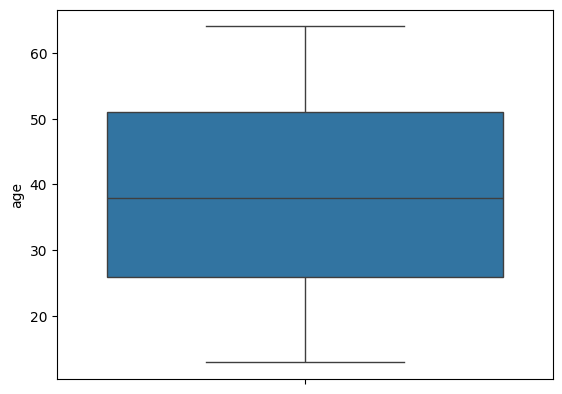

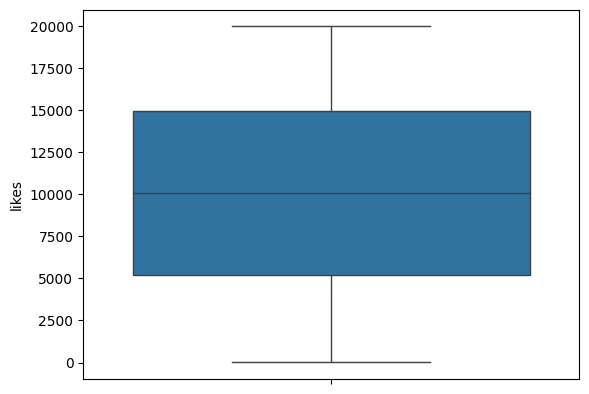

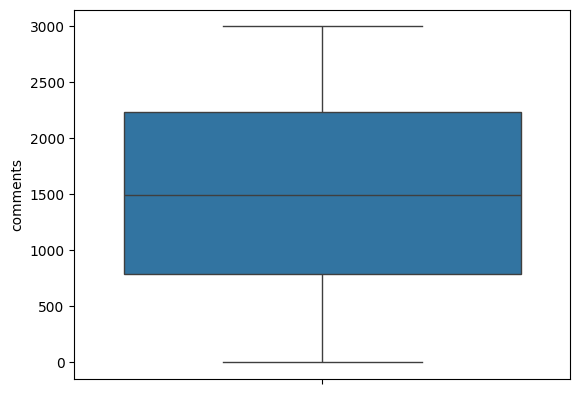

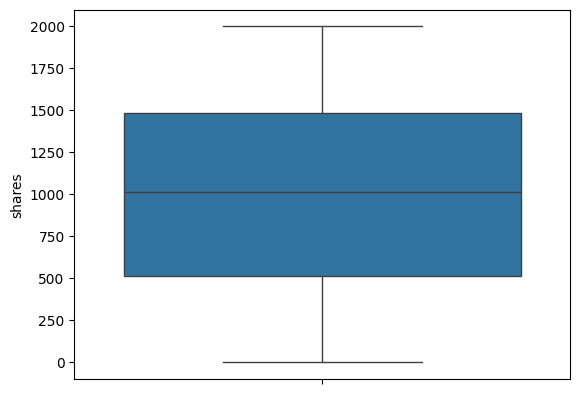

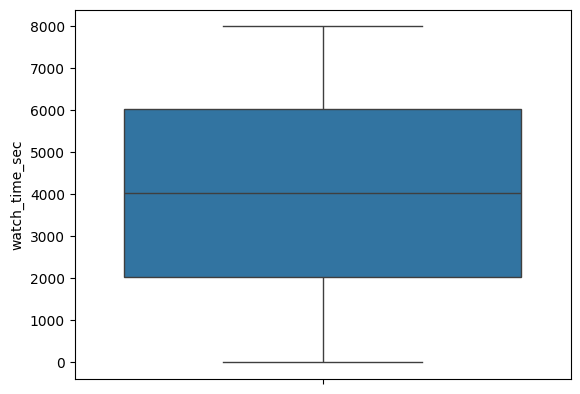

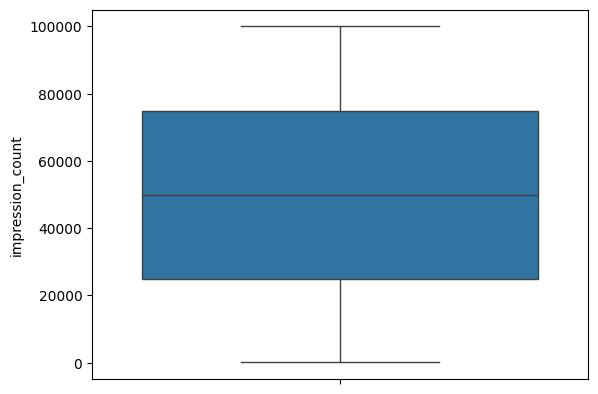

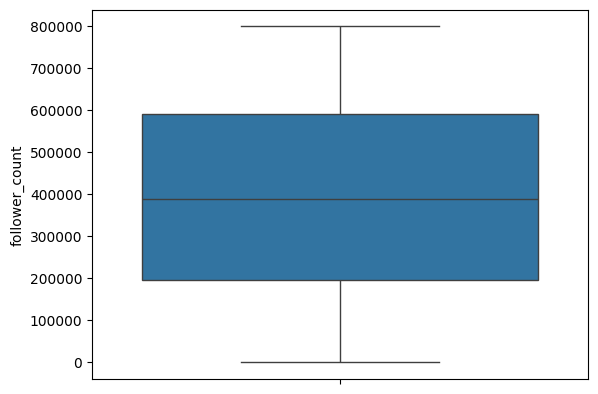

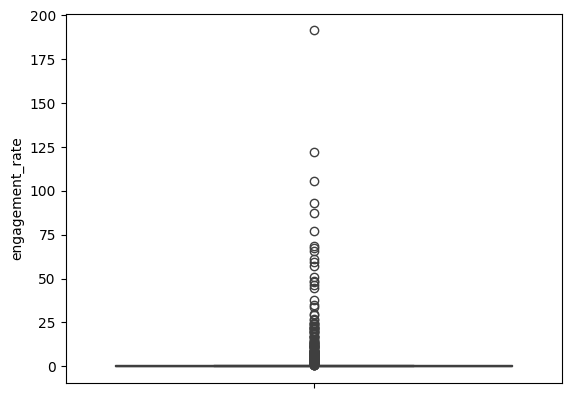

In [ ]:
for col in numerical_cols:
  sns.boxplot(df[col])
  plt.show()

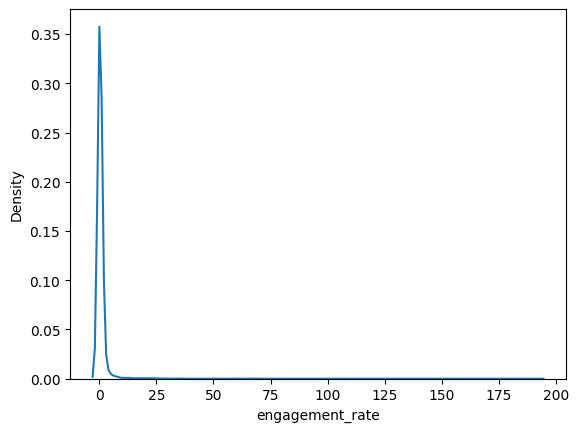

In [ ]:
# Handling Outliers
# From the above skew and kurtosis value it is clear that engagement_rate has extreme outliers

#before cleaning outliers

sns.kdeplot(df['engagement_rate'])
plt.show()

In [ ]:
df[df['engagement_rate'] < 0]

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,...,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,engagement_score,hashtag_count


In [ ]:
df['engagement_rate'].describe()

,engagement_rate
count,4991.000000
mean,0.964971
std,5.322732
min,0.006363
25%,0.145709
50%,0.253806
75%,0.504695
max,191.504348


In [ ]:
# Handling outliers with percentile capping method

lower = df['engagement_rate'].quantile(0.25)
upper = df['engagement_rate'].quantile(0.75)

df['engagement_rate'] = df['engagement_rate'].clip(lower,upper)

# Extreme values in engagement_rate were handled using percentile capping to reduce skewness while preserving meaningful viral-content behavior.

In [ ]:
df['engagement_rate'].skew()

np.float64(0.3759959743084219)

In [ ]:
df['engagement_rate'].kurt()

np.float64(-1.5078173954329843)

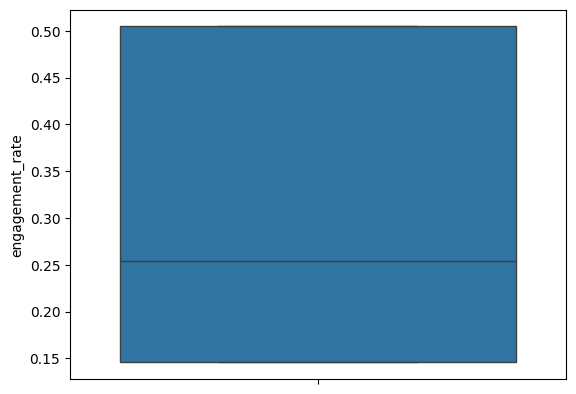

In [ ]:
sns.boxplot(df['engagement_rate'])
plt.show()

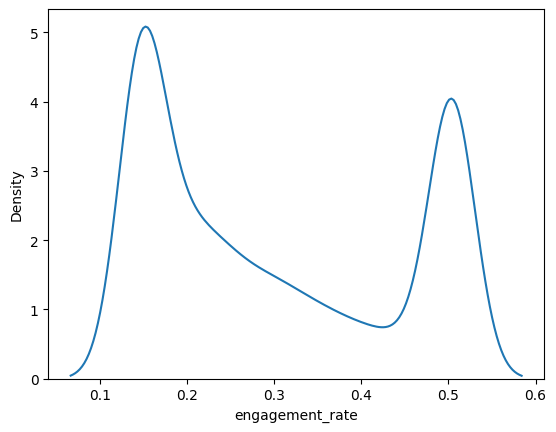

In [ ]:
sns.kdeplot(df['engagement_rate'])
plt.show()

# **Task 6 — Data Visualization (Min. 8 Plots Required)**
**Matplotlib**

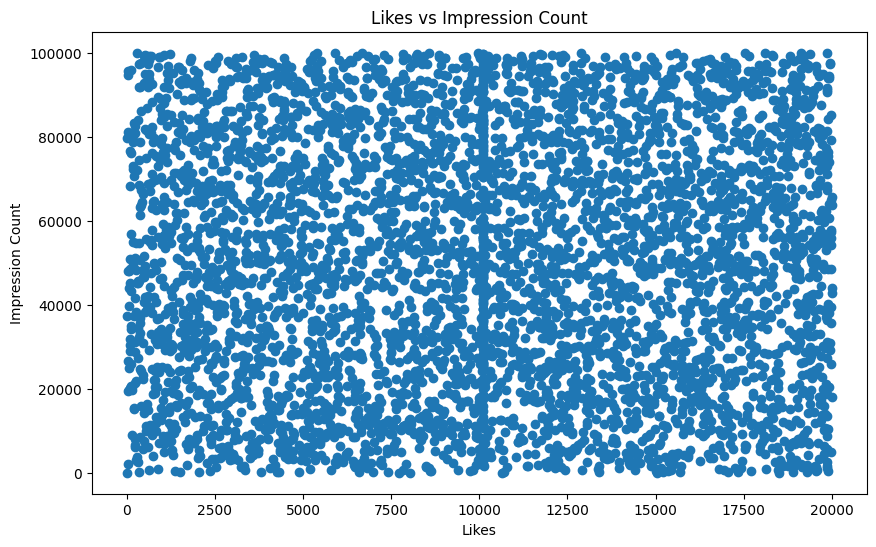

In [ ]:
# Scatter: likes vs impressions
plt.figure(figsize=(10,6))
plt.scatter(df['likes'], df['impression_count'])

# Labels

plt.xlabel('Likes')
plt.ylabel('Impression Count')
plt.title('Likes vs Impression Count')

plt.show()

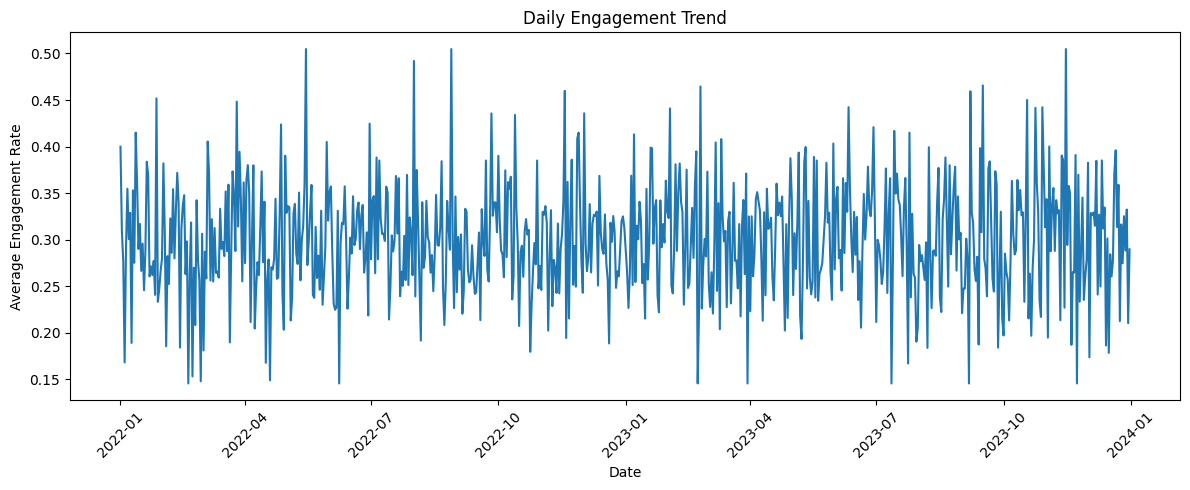

In [ ]:
# Line: daily engagement trend
plt.figure(figsize=(12,5))

daily_engagement = df.groupby(df['posted_at'].dt.date)[
    'engagement_rate'
].mean()

# ● Line plot

plt.plot(daily_engagement)

# Labels

plt.xlabel('Date')
plt.ylabel('Average Engagement Rate')
plt.title('Daily Engagement Trend')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

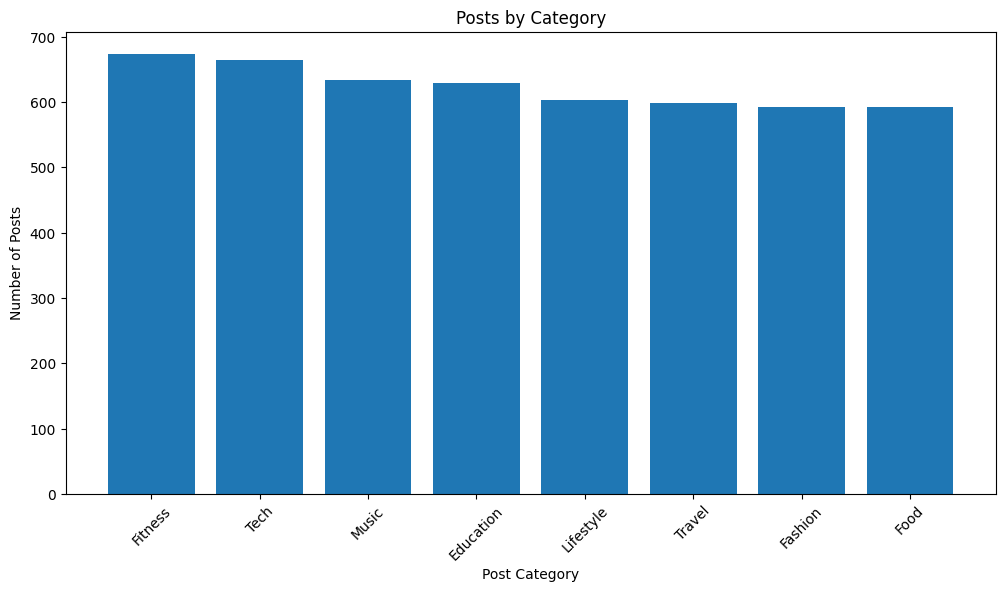

In [ ]:
#Bar: posts by category
# ● Count posts by category
plt.figure(figsize=(12,6))
category_counts = df['post_category'].value_counts()

# ● Bar plot

plt.bar(category_counts.index, category_counts.values)

# Labels

plt.xlabel('Post Category')
plt.ylabel('Number of Posts')
plt.title('Posts by Category')

plt.xticks(rotation=45)

plt.show()

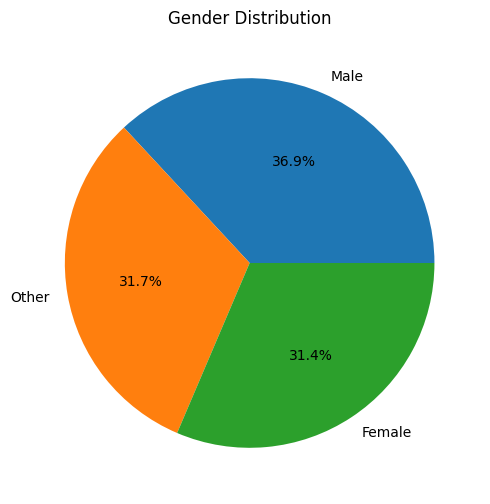

In [ ]:
# Pie: gender distribution

gender_counts = df['gender'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(gender_counts,labels=gender_counts.index,autopct='%1.1f%%')

plt.title('Gender Distribution')
plt.show()

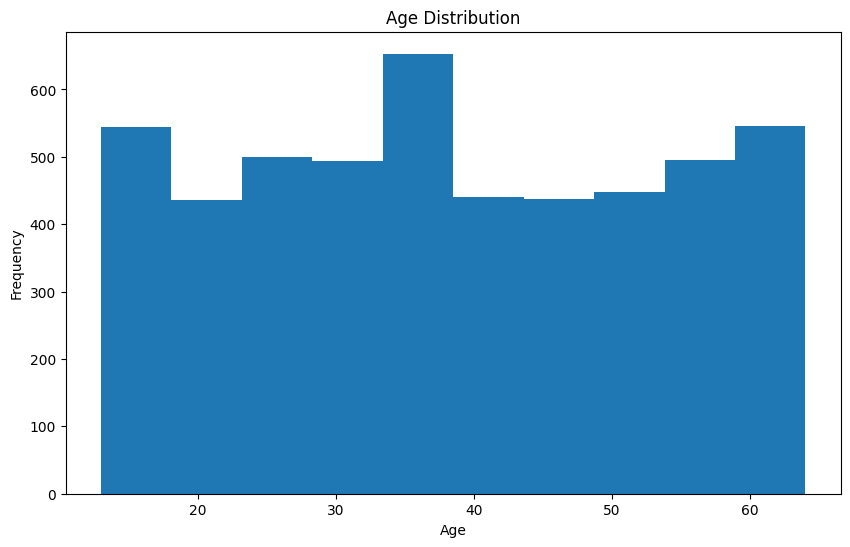

In [ ]:
# Histogram: age

plt.figure(figsize=(10,6))

plt.hist(df['age'],bins=10)

plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution')
plt.show()

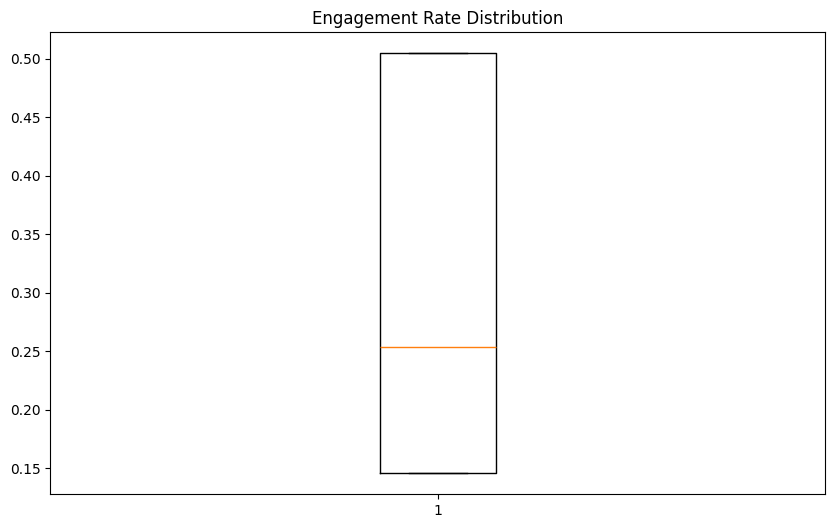

In [ ]:
# ○ Box: engagement rate

plt.figure(figsize=(10,6))

plt.boxplot(df['engagement_rate'])
plt.title('Engagement Rate Distribution')

plt.show()

**seaborn**

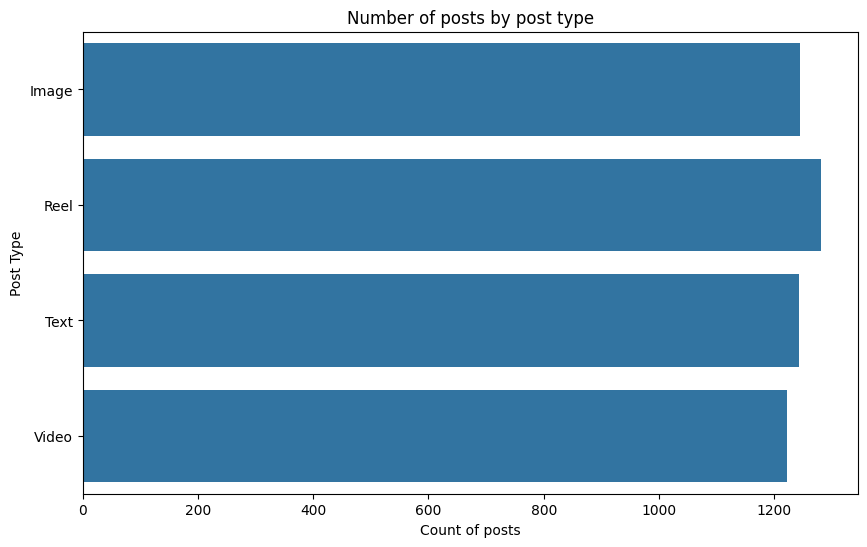

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(df['post_type'])

plt.xlabel('Count of posts')
plt.ylabel('Post Type')
plt.title('Number of posts by post type')
plt.show()

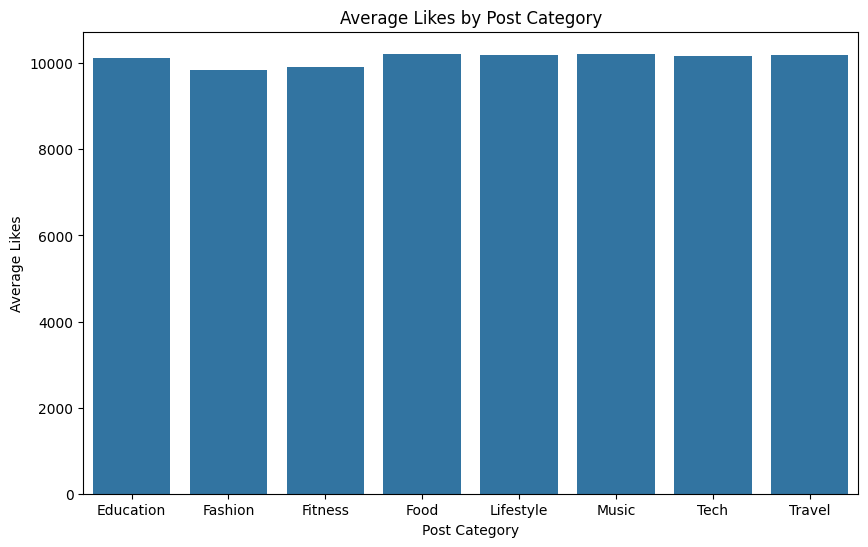

In [ ]:
# Bar plot: avg likes by category

avg_likes = df.groupby('post_category')['likes'].mean().reset_index()

plt.figure(figsize=(10,6))

sns.barplot(x='post_category',y='likes',data=avg_likes)
plt.xlabel('Post Category')
plt.ylabel('Average Likes')
plt.title('Average Likes by Post Category')
plt.show()

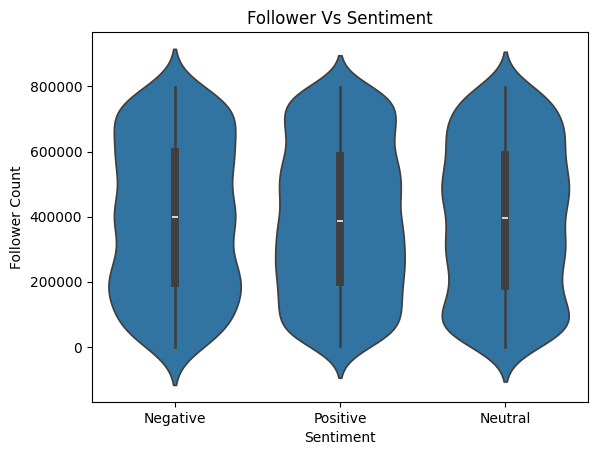

In [ ]:
# Violin: followers vs sentiment

sns.violinplot(x='sentiment', y='follower_count', data=df)

plt.title('Follower Vs Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Follower Count')

plt.show()

In [ ]:
#Pair plot: numeric features

sns.pairplot(data=df[numerical_cols])
plt.show()

Output hidden; open in https://colab.research.google.com to view.

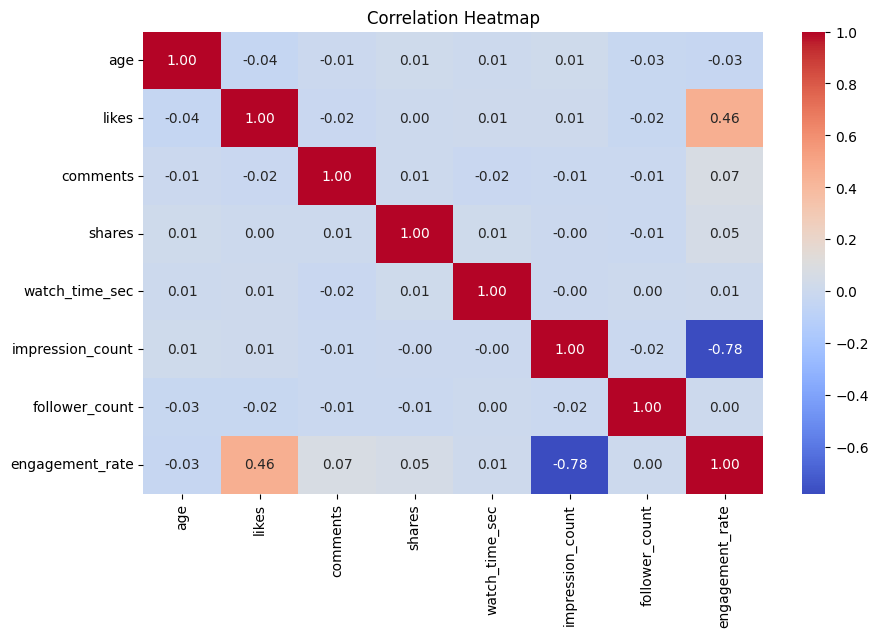

In [ ]:
corr = df[numerical_cols].corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr,annot=True,cmap='coolwarm',fmt='.2f')

plt.title('Correlation Heatmap')
plt.show()

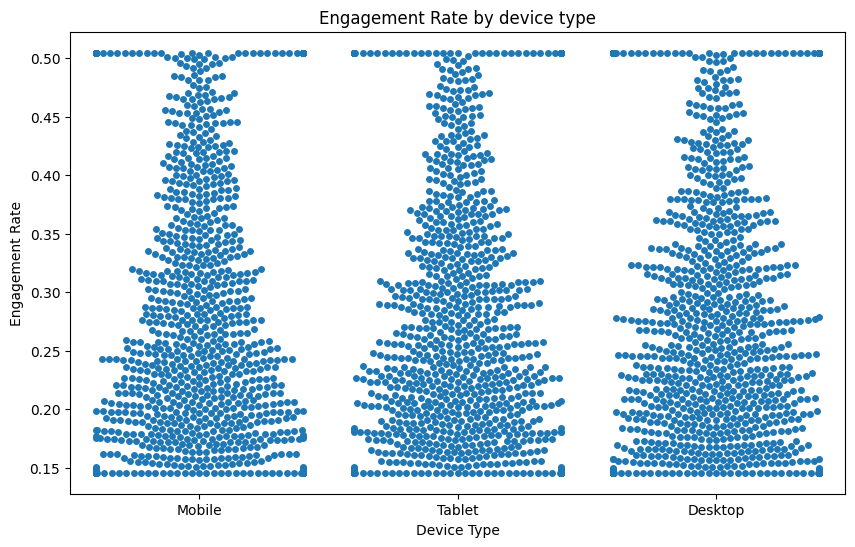

In [ ]:
# Swarm plot: engagement vs device

plt.figure(figsize=(10,6))

sns.swarmplot(x='device_type',y='engagement_rate',data=df)

plt.xlabel('Device Type')
plt.ylabel('Engagement Rate')
plt.title('Engagement Rate by device type')
plt.show()

#  **Plotly (Interactive)**
# ○ Interactive line chart/bar chart/bubble/scatter chart

In [ ]:
# line chart
daily_engagement = df.groupby(df['posted_at'].dt.date)[
    'engagement_rate'
].mean().reset_index()

daily_engagement.columns = ['date','avg_engagement_rate']

In [ ]:
import plotly.express as px

fig = px.line(daily_engagement,
              x='date',
              y='avg_engagement_rate',
              title='Daily Engagement Trend')

fig.show()

In [ ]:
# Bar chart
avg_likes = df.groupby('post_category')['likes'].mean().reset_index()

fig = px.bar(avg_likes,
             x='post_category',
             y='likes',
             title='Average Likes by Category')

fig.show()

In [ ]:
# Interactive Scatter Plot
fig = px.scatter(df,
                 x='likes',
                 y='comments',
                 title='Likes vs Comments')

fig.show()

In [ ]:
# Interactive Bubble Chart

fig = px.scatter(df,
                 x='likes',
                 y='comments',
                 size='shares',
                 color='sentiment',
                 hover_data=['post_category'],
                 title='Engagement Bubble Chart')

fig.show()

# **Final Insights should include the following analysis**

In [ ]:
# Content Performance
# ○ Which post types have the highest engagement?

In [ ]:
df.groupby('post_type')['engagement_rate'].mean().sort_values(ascending=False)

,engagement_rate
post_type,
Image,0.302078
Video,0.300794
Text,0.300595
Reel,0.296612


* Image posts have the highest average engagement rate (0.302), indicating slightly better audience interaction compared to other post types.
* Video and text posts show nearly identical engagement levels, suggesting consistent performance across these formats.
* Reel posts have the lowest engagement rate (0.297), but the overall differences between post types are very small, indicating balanced engagement across content formats.

In [ ]:
# Best-performing content category?
df.groupby('post_category')['engagement_score'].mean().sort_values(ascending=False)

,engagement_score
post_category,
Music,12802.001577
Food,12720.386824
Tech,12686.500752
Travel,12651.879800
Lifestyle,12647.357616
Education,12571.603175
Fitness,12450.354599
Fashion,12352.902192


* Music category has the highest average engagement score (12802), indicating it generates the strongest overall audience interaction.
* Food and Tech content also perform well, showing high engagement scores and strong user interest.
* Fashion category has the lowest engagement score (12353) among all categories, suggesting comparatively lower audience engagement.

In [ ]:
# Which countries have the highest average engagement rate?

df.groupby('country')['engagement_rate'].mean().sort_values(ascending=False)

,engagement_rate
country,
Germany,0.307575
Australia,0.307417
Canada,0.305134
Japan,0.304214
UAE,0.303594
Brazil,0.301812
France,0.295413
USA,0.293584
India,0.291551


* Germany and Australia have the highest average engagement rates (0.308), indicating stronger audience interaction compared to other countries.
* Canada, Japan, and UAE also show high engagement performance, suggesting active and responsive user audiences.
* UK and India have the lowest engagement rates in the dataset, though the differences across countries are relatively small overall.

In [ ]:
# User Trends
# ○ How age affects engagement

df.groupby('age')['engagement_rate'].mean().sort_values(ascending=False)

,engagement_rate
age,
17,0.330076
33,0.329973
24,0.326034
34,0.321177
52,0.319016
15,0.318638
30,0.318545
14,0.316609
49,0.316459


* Users aged 17 and 33 have the highest engagement rates (around 0.33), indicating stronger interaction among these age groups.
* Engagement remains relatively stable across most ages, generally ranging between 0.28 and 0.32, showing no major age-based variation.
* Users aged 40 and 28 show the lowest engagement rates, suggesting comparatively lower audience interaction in these age groups.

In [ ]:
# Performance difference for verified accounts
df.groupby('is_verified')['engagement_rate'].mean()

,engagement_rate
is_verified,
False,0.301557
True,0.285273


* Non-verified accounts have a higher average engagement rate (0.302) compared to verified accounts (0.285).
* This suggests that non-verified users may generate more audience interaction, possibly due to more relatable or highly active content.
* Verified accounts show slightly lower engagement, indicating that account verification alone does not guarantee higher audience interaction.

In [ ]:
# Behavioral Insights
# ○ Best time of day for impressions

best_day_of_week = df.groupby(df['posted_at'].dt.day_name())[
    'impression_count'
].mean().round(2).sort_values(ascending=False)

print(best_day_of_week)

posted_at
Tuesday      51354.27
Saturday     50945.23
Sunday       50374.73
Monday       50013.22
Wednesday    49914.23
Friday       49414.08
Thursday     48117.96
Name: impression_count, dtype: float64


* Tuesday has the highest average impression count (51,354), indicating it is the best-performing day for reaching a larger audience.
* Saturday and Sunday also show high impression counts, suggesting stronger user activity and visibility during weekends.
* Thursday has the lowest average impressions (48,118), indicating comparatively lower audience reach on that day.

In [ ]:
# Device type impact on watch time

df.groupby('device_type')['watch_time_sec'].mean().round(2).sort_values(ascending=False)

,watch_time_sec
device_type,
Mobile,4087.61
Tablet,3980.80
Desktop,3975.81


* Mobile devices have the highest average watch time (4087.61 seconds), indicating users on mobile are more engaged with content consumption.
* Tablet and Desktop users show very similar watch times, both slightly lower than mobile users.
* The results suggest that mobile platforms may be the most effective channel for maximizing user watch time and engagement.

In [ ]:
# Sentiment Analysis
# ○ Which sentiment performs best

df.groupby('sentiment')['engagement_score'].mean().round(2).sort_values(ascending=False)

,engagement_score
sentiment,
Negative,12728.70
Positive,12666.40
Neutral,12443.57


* Negative sentiment posts have the highest average engagement score (12728.70), indicating that emotionally strong or controversial content attracts more audience interaction.
* Positive sentiment content also performs well, showing high engagement and strong user response.
* Neutral sentiment posts have the lowest engagement score (12443.57), suggesting less audience interaction compared to emotionally driven content.

In [ ]:
# ○ Behavior of negative/neutral sentiment posts

df[df['sentiment'].isin(['Negative','Neutral'])].groupby('sentiment')[[
    'likes',
    'comments',
    'shares',
    'watch_time_sec',
]].mean().round(2)


,likes,comments,shares,watch_time_sec
sentiment,,,,
Negative,10208.07,1514.57,1006.06,4055.65
Neutral,9918.59,1528.15,996.83,4029.15


* Negative sentiment posts receive higher average likes (10208) and shares (1006), suggesting emotionally charged content encourages stronger audience reactions and content sharing.
* Neutral posts generate slightly more comments (1528) than negative posts, indicating users may engage in discussions even without strong emotional tone.
* Watch time for both sentiments is very similar, showing that users spend nearly the same amount of time consuming both negative and neutral content.

### **Conclusion**

* Image posts showed the highest engagement rate, while reels had slightly lower engagement compared to other post types.
* Education and Music categories performed best in audience engagement, whereas Food and Fashion categories showed comparatively lower performance.
* Germany and Australia recorded the highest engagement rates among countries, indicating stronger audience interaction in these regions.
* Mobile users had the highest average watch time, suggesting mobile devices are the dominant platform for content consumption.
* Non-verified accounts achieved higher engagement rates than verified accounts, indicating that verification alone does not guarantee better audience interaction.
* Negative sentiment posts generated the highest engagement scores, showing that emotionally driven content tends to attract more reactions and shares.
* Tuesdays and weekends produced higher impression counts, making them effective periods for maximizing content visibility and reach.
* Overall, audience engagement was influenced by multiple factors including content type, sentiment, device usage, posting time, and user behavior patterns.

In [ ]:
df.to_csv('social_media_analysis_cleaned.csv',index=False)